# Transformer-Based Segmentation with SegFormer

## SegFormer: Transformer-Based Semantic Segmentation

SegFormer is a powerful transformer-based model designed for lightweight and high-performance segmentation. Unlike classical CNN-based models, SegFormer uses attention to understand both global and local structures.

Outline:
- Load dataset
- Use a pretrained SegFormer model
- Fine-tune it on a small subset
- Evaluate using mIoU

In [1]:
# Install dependencies
!pip install -q transformers timm torchvision albumentations

In [2]:
# Load Dataset
from torchvision.datasets import OxfordIIITPet
dataset = OxfordIIITPet(root="./data", target_types="segmentation", download=True)

100%|██████████| 792M/792M [00:29<00:00, 26.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.2MB/s]


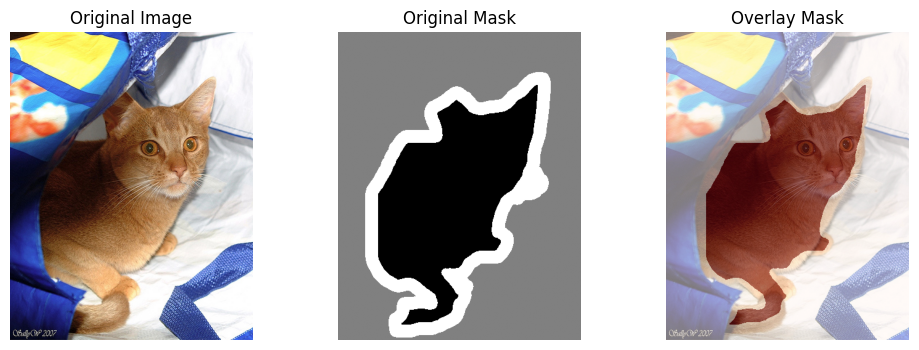

In [3]:
# Visualize Sample
import matplotlib.pyplot as plt
import numpy as np

image, mask = dataset[0]
image = np.array(image)
mask = np.array(mask)

binary_mask = (mask == 1).astype(np.uint8)

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("Original Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image)
plt.imshow(binary_mask, alpha=0.5, cmap='Reds')
plt.title("Overlay Mask")
plt.axis("off")

plt.show()

In [4]:
# Preprocess and Dataloader
import torch
from torch.utils.data import Dataset
from torchvision.transforms import functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

# Albumentations transforms
transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

class PetSegmentationDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, mask = self.base[idx]
        image = np.array(image)
        mask = np.array(mask)
        mask = (mask == 1).astype(np.int64)  # pet = 1, others = 0

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask


In [5]:
# Load pretrained model
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,  # binary: pet vs background
    ignore_mismatched_sizes=True
)

processor = SegformerImageProcessor(do_resize=True, size=512, do_normalize=True)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [6]:
import time
from torch.utils.data import DataLoader
from torch.optim import Adam
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

train_data = PetSegmentationDataset(dataset, transform=transform)
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)

optimizer = Adam(model.parameters(), lr=3e-5)

model.train()
for epoch in range(3):
    start_time = time.time()  # Start time for the epoch
    total_loss = 0
    for img, mask in train_loader:
        img = img.to(device)
        mask = mask.to(device).long()  # ✅ Fix: convert mask to long type

        outputs = model(pixel_values=img, labels=mask)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    end_time = time.time()  # End time for the epoch
    epoch_duration = end_time - start_time

    print(f"Epoch {epoch+1} - Loss: {total_loss / len(train_loader):.4f} - Time: {epoch_duration:.2f}s")

Epoch 1 - Loss: 0.2105 - Time: 189.50s
Epoch 2 - Loss: 0.1197 - Time: 185.33s
Epoch 3 - Loss: 0.0989 - Time: 185.13s


In [7]:
# Evaluation
def compute_mIoU(pred, gt, num_classes=2):
    iou = []
    pred = pred.flatten()
    gt = gt.flatten()
    for cls in range(num_classes):
        i = ((pred == cls) & (gt == cls)).sum()
        u = ((pred == cls) | (gt == cls)).sum()
        if u > 0:
            iou.append(i / u)
    return np.mean(iou)

model.eval()
with torch.no_grad():
    import torch.nn.functional as F

    img, gt = train_data[0]
    img_input = img.unsqueeze(0).to(device)

    # inference
    output = model(pixel_values=img_input)
    pred = output.logits
    pred_resized = F.interpolate(pred, size=gt.shape[-2:], mode='bilinear', align_corners=False)
    pred_mask = pred_resized.argmax(1).squeeze().cpu()
    iou = compute_mIoU(pred_mask, gt)
    print("mIoU:", iou)


mIoU: 0.92195415


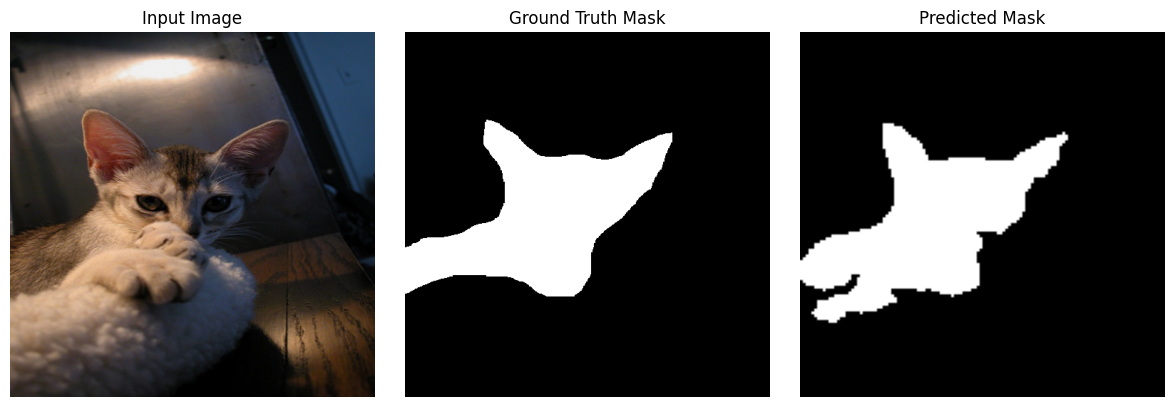

In [8]:
# Result visualization
model.eval()
with torch.no_grad():
    img, gt = train_data[10]  # Random test sample
    img_input = img.unsqueeze(0).to(device)
    output = model(pixel_values=img_input)
    pred_mask = output.logits.argmax(1).squeeze().cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt.cpu().numpy(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()


# Prompt-Based Segmentation using SAM (Segment Anything Model)

## ✂️ Segment Anything (SAM) – Prompt-Based Segmentation

SAM is a zero-shot segmentation model by Meta AI that can segment any object given:
- A point
- A box
- A mask prompt

In this demo:
- We use the SAM model via HuggingFace
- We apply segmentation using a **point prompt**
- Dataset: Oxford-IIIT Pet (we provide our own prompts)

SAM doesn’t require training – it performs segmentation with powerful generalization.


In [9]:
# Install dependencies
!git clone https://github.com/facebookresearch/segment-anything.git
%cd segment-anything
!pip install -e .
!pip install opencv-python matplotlib

Cloning into 'segment-anything'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 18.31 MiB | 38.82 MiB/s, done.
Resolving deltas: 100% (161/161), done.
/content/segment-anything
Obtaining file:///content/segment-anything
  Preparing metadata (setup.py) ... done
  Running setup.py develop for segment_anything


In [10]:
# Download SAM Model
import requests

url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
output_path = "sam_vit_b.pth"

# Download the file
with open(output_path, "wb") as f:
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
        print("Downloaded sam_vit_b.pth")
    else:
        print("Failed to download. Status code:", response.status_code)


Downloaded sam_vit_b.pth


In [11]:
# Load SAM model
from segment_anything import sam_model_registry, SamPredictor
import cv2
import numpy as np
from PIL import Image
import torch

# Load the model
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda")

predictor = SamPredictor(sam)


In [12]:
# Load dataset
from torchvision.datasets import OxfordIIITPet

dataset = OxfordIIITPet(root="./data", target_types="segmentation", download=True)

100%|██████████| 792M/792M [00:32<00:00, 24.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.3MB/s]


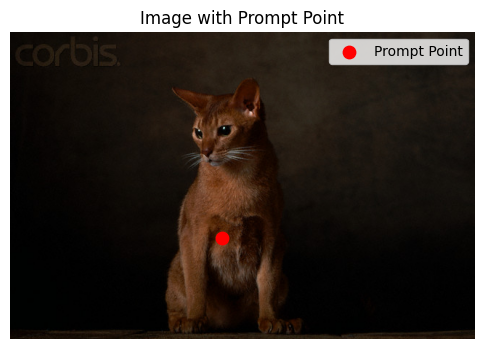

In [13]:
import matplotlib.pyplot as plt

image, mask = dataset[15] # Picking sample, you can adjust here
image = image.convert("RGB")
image_np = np.array(image)
mask_np = np.array(mask)

# Give a point prompt and predict
predictor.set_image(image_np)

pet_pixels = np.argwhere(mask_np == 1)
prompt_point = pet_pixels[len(pet_pixels) // 2][::-1]  # (x, y) you can adjust here

input_point = np.array([prompt_point])
input_label = np.array([1])

# Visualize prompt point
plt.figure(figsize=(6, 6))
plt.imshow(image_np)
plt.scatter(*prompt_point, color='red', s=80, label="Prompt Point")
plt.title("Image with Prompt Point")
plt.axis("off")
plt.legend()
plt.show()


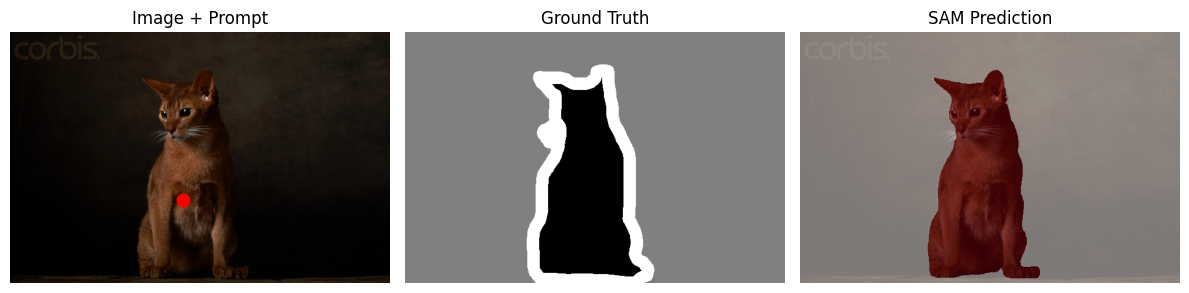

In [14]:
# Predict and visualize
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=False
    )

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.scatter(*prompt_point, c="red", s=80)
plt.title("Image + Prompt")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_np)
plt.imshow(masks[0], cmap="Reds", alpha=0.5)
plt.title("SAM Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()


# Zero-Shot Segmentation using CLIPSeg

## 🧪 Zero-Shot Segmentation using CLIPSeg

CLIPSeg is a zero-shot segmentation model that uses **text prompts** to guide segmentation, enabling flexible and fast annotation with **no manual labels**. It combines **CLIP** for vision-language understanding and **ViT** for segmentation.

### ✅ Advantages:
- No need for dataset-specific training
- Can work with **free-text prompts** like "a cat", "a dog", "the pet"
- Lightweight and easy to use

### ❌ Limitations:
- Not pixel-accurate like U-Net
- May fail with complex or unclear prompts


In [15]:
# Install required packages
!pip install -q transformers timm torchvision matplotlib

In [35]:
# Load CLIPSeg model from Hugging Face
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
import torch
import numpy as np
from torchvision.datasets import OxfordIIITPet
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined").to(device)
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
# Load a test image
dataset = OxfordIIITPet(root="./data", target_types="segmentation", download=True)

sample_idx = 20 # pick a dataset, you can adjust here
image, gt_mask = dataset[sample_idx]
image = image.convert("RGB")

In [37]:
prompt="a cat"

In [38]:
# Preprocess
inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt"
).to(device)

# Predict
with torch.no_grad():
    outputs = model(**inputs)
    pred_mask = outputs.logits[0]  # shape: [H, W]

# Normalize mask
pred_mask = pred_mask.cpu().numpy()
pred_mask = (pred_mask - pred_mask.min()) / (pred_mask.max() - pred_mask.min())

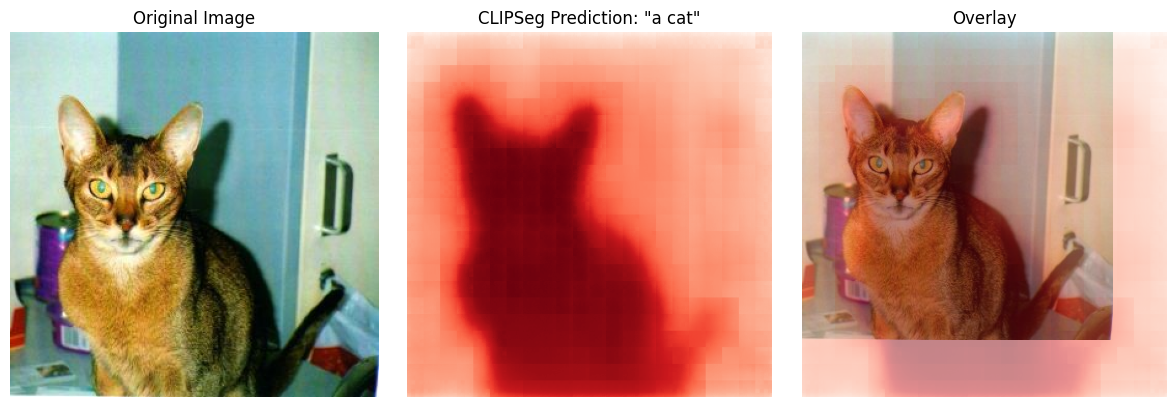

In [39]:
# Convert image to NumPy
image_np = np.array(image)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred_mask, cmap="Reds")
plt.title(f"CLIPSeg Prediction: \"{prompt}\"")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_np)
plt.imshow(pred_mask, cmap="Reds", alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

# Real-Time Segmentation

## Semantic Segmentation with DeepLabV3

DeepLabV3 is a state-of-the-art model for semantic segmentation that uses atrous convolution and spatial pyramid pooling to capture context at multiple scales. It is known for high accuracy, especially on large datasets like Cityscapes and PASCAL VOC.

## Highlights:
- High segmentation accuracy
- Pretrained on Cityscapes and COCO
- Great for general-purpose and academic tasks

In [23]:
# Install dependencies
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

In [24]:
%cd /content/
!wget "https://upload.wikimedia.org/wikipedia/commons/b/bd/Moscow%2C_Taganka%2C_people_April_2025_18.jpg" -O "image.jpg"


/content
--2026-05-07 03:35:41--  https://upload.wikimedia.org/wikipedia/commons/b/bd/Moscow%2C_Taganka%2C_people_April_2025_18.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.153.240, 2620:0:860:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.153.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3005588 (2.9M) [image/jpeg]
Saving to: ‘image.jpg’

image.jpg           100%[===================>]   2.87M  9.53MB/s    in 0.3s    

2026-05-07 03:35:42 (9.53 MB/s) - ‘image.jpg’ saved [3005588/3005588]



In [25]:
# Load image from URL
image = Image.open("image.jpg").convert("RGB")
original = image.copy()
image = image.resize((513, 513))  # Expected input size for DeepLabV3

In [26]:
# Transform: normalize as per ImageNet
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
input_tensor = preprocess(image).unsqueeze(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_tensor = input_tensor.to(device)

In [27]:
# Load model
model = models.segmentation.deeplabv3_resnet101(pretrained=True).eval().to(device)

# Predict
with torch.no_grad():
    output = model(input_tensor)['out'][0]
pred = output.argmax(0).byte().cpu().numpy()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 182MB/s]


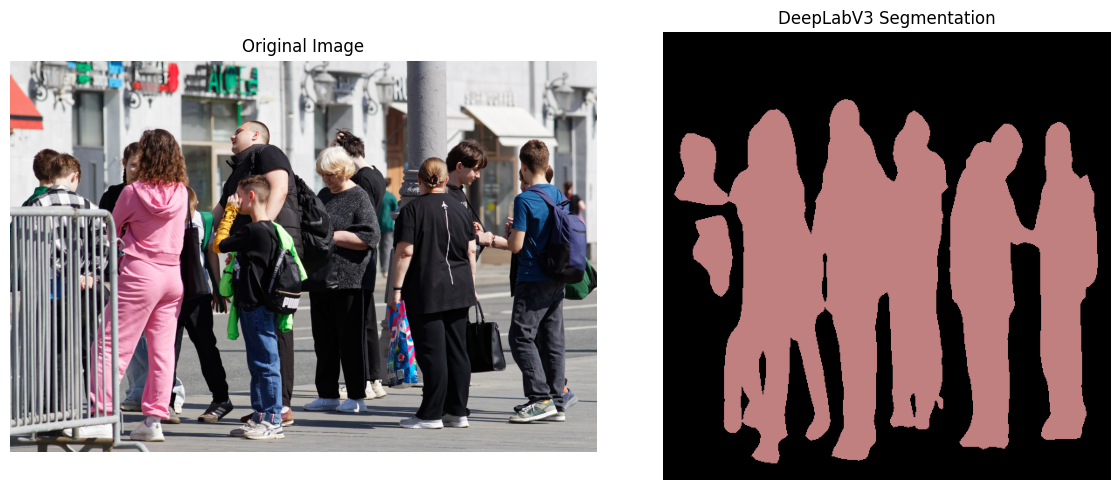

In [28]:
# Color map (21 classes - PASCAL VOC)
def decode_segmap(mask):
    label_colors = np.array([
        (0, 0, 0), (128, 0, 0), (0, 128, 0), (128, 128, 0),
        (0, 0, 128), (128, 0, 128), (0, 128, 128), (128, 128, 128),
        (64, 0, 0), (192, 0, 0), (64, 128, 0), (192, 128, 0),
        (64, 0, 128), (192, 0, 128), (64, 128, 128), (192, 128, 128),
        (0, 64, 0), (128, 64, 0), (0, 192, 0), (128, 192, 0), (0, 64, 128)
    ])
    r = np.zeros_like(mask).astype(np.uint8)
    g = np.zeros_like(mask).astype(np.uint8)
    b = np.zeros_like(mask).astype(np.uint8)

    for l in range(0, 21):
        idx = mask == l
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]

    rgb = np.stack([r, g, b], axis=2)
    return rgb

decoded = decode_segmap(pred)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(decoded)
plt.title("DeepLabV3 Segmentation")
plt.axis("off")
plt.tight_layout()
plt.show()

# Quiz

## 1. Quiz: Transformer-Based Segmentation with SegFormer


- Fine-tune the **SegFormer** model using a different dataset of your choice.
- Split the dataset into **training** and **test** sets.
- Your goal is to **achieve the highest IoU (Intersection over Union)** possible on the test set.

## 2. Quiz: Prompt-Based Segmentation using SAM (Segment Anything Model)

Use **Segment Anything (SAM)** to segment **multiple objects** in one image using **multiple prompt points**.

1. **Choose or upload** an image that contains at least **2–3 distinct objects**  
   _Example_: a person and a pet, or a street scene with cars and signs

2. **Display the image** using `matplotlib`

3. **Define multiple prompt points**

4. [Bonus] Define negative label to a certain object.

5. Visualize the result


## 3. Quiz: Zero-Shot Segmentation using CLIPSeg

Use **CLIPSeg** to perform segmentation on an image using **natural language prompts**, without any fine-tuning or training.

Use this image: https://upload.wikimedia.org/wikipedia/commons/8/8b/Alg%C3%A9rie_-_Arm%C3%A9nie_-_20140531_-_Yacine_Brahimi_%28Alg%29_face_%C3%A0_Taron_Voskanyan_%28Arm%29.jpg

1. Download and Load the image

2. Try to segment the referee and the attacking player using your own prompt

3. **Visualize the result**:
   - Display the original image
   - Overlay the predicted mask using transparency (e.g., red heatmap)